# Industrial defect intelligence: reproducible fresh experiment

**Research question:** To what extent does end-to-end representation learning improve six-class steel-surface defect classification over handcrafted HOG features, when validation, image conditions and practical computational costs are controlled?

This notebook is the complete implementation. Run it from an otherwise empty project folder or the project root, using a fresh kernel and **Run All**. It acquires raw data if absent and creates a new timestamped output directory on every execution. No previous notebook, manifest, checkpoint, report or experiment output is required. All training executes by default. Allow time for both five-fold CNN experiments on CPU.

Install into the notebook's Python environment before running:

```bash
python -m pip install numpy pandas matplotlib pillow scikit-learn scikit-image joblib torch==2.14.0 torchvision==0.29.0 captum==0.9.0 tqdm scipy ipython ipykernel nbformat nbclient jupyterlab
```

Torchvision is included for the specified environment, although this custom CNN does not use pretrained models. SciPy supplies the explicitly defined image-condition operators. The remaining Jupyter packages support execution and display. Exact installed versions and machine details are saved by the run.

The task assigns an already selected defect image to one of six classes. **There is no normal or defect-free class.** This experiment cannot measure defect-versus-normal detection, production false-alarm rates or localisation accuracy. The notebook generates numerical evidence; its prose explains methods rather than interpreting run-dependent results.

## 1. Experimental controls and predeclared analysis

Pool the source containers, audit image integrity, exclude exact duplicate content deterministically, and create an image-level stratified 80/20 development/test split with seed 42. Create shared five-fold stratified validation assignments within development. The source folder names do not define this experiment's partitions. No bounding-box annotation is a classifier input.

The baseline uses fixed native-resolution HOG [3] and six SVM [4] candidates: linear and RBF kernels, each with C in {0.1, 1, 10}; RBF gamma is `scale`. Fit StandardScaler inside each training fold. Select the highest mean fold macro F1, with candidate order resolving exact ties. HOG parameters are fixed rather than searched.

The custom CNN uses three convolution, batch normalisation, ReLU and pooling blocks, global average pooling and dropout. CPU execution, one seeded initialisation per fold, AdamW, cross-entropy and no augmentation give a bounded comparison. Checkpoint selection uses strictly improving validation macro F1, earliest exact tie, patience five and an initial cap of 25 epochs. Validation loss is diagnostic only.

**Single controlled epoch-cap sensitivity:** rerun all five folds from the same seeds with cap 40, changing no other setting. Adopt 40 only if at least two folds improve by at least 0.005 macro F1, each originally stopped solely at the 25 ceiling, and each selects an epoch beyond 25. Retain 25 as adequate under this check if absolute mean change is at most 0.002, no fold improves by at least 0.005, and at least three extended folds stop by patience before 40. Otherwise retain 25 provisionally with inconclusive adequacy. Failure of common-prefix agreement within 1e-10 prevents automatic adoption. These are pragmatic thresholds, not significance levels. No further tuning follows. Refit for the ceiling of the median selected epoch under the chosen cap.

Before unlocking the test images, freeze both fitted models, normalisation, subgroup cut points and stress-test severities. Evaluate each clean test image once per model for the primary comparison. Later diagnostics reuse those predictions; perturbations and timing are explicitly separate evaluations of frozen models.

Accuracy measures overall correctness. Macro precision, recall and F1 weight the six classes equally; F1 is averaged across classwise F1 values. Undefined class precision is set to zero. Report class support and confusion counts. Selection CV is not nested CV: reused validation folds and checkpoint selection introduce optimism, and fold SD is descriptive rather than a confidence interval. Equal folds do not equalise model search budgets. No formal significance claim is made.

In [1]:
from pathlib import Path, PurePosixPath
from datetime import datetime, timezone
from time import perf_counter
from importlib.metadata import version
import os, sys, platform, json, hashlib, random, math, re, stat, shutil, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, laplace
from skimage.feature import hog
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from captum.attr import LayerGradCam, LayerAttribution
from tqdm.auto import tqdm
from IPython.display import display

ROOT = Path.cwd().resolve()
RUN = ROOT / 'outputs' / ('fresh_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ'))
RUN.mkdir(parents=True, exist_ok=False)
DATA = ROOT / 'data' / 'NEU-CLS'
SEED = 42
CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
HOG = dict(orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2), block_norm='L2-Hys', transform_sqrt=False, feature_vector=True)
CANDIDATES = [dict(kernel=k, C=c, gamma='scale') for k in ['linear','rbf'] for c in [0.1,1.0,10.0]]
CONFIG = dict(batch_size=32, learning_rate=0.001, weight_decay=0.0001, dropout=0.25, patience=5, caps=[25,40], threads=min(4,os.cpu_count() or 1))
STRESS = dict(blur_sigma=0.6, brightness_factors=[0.9,1.1], contrast_factor=0.9, noise_sd=0.02, seed=2026)
torch.set_num_threads(CONFIG['threads'])
torch.use_deterministic_algorithms(True)
def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
seed_all(SEED)
def save_json(name, value):
    (RUN/name).write_text(json.dumps(value, indent=2, default=lambda x: x.item() if isinstance(x,np.generic) else str(x)), encoding='utf-8')
def sha(path):
    with Path(path).open('rb') as f: return hashlib.file_digest(f,'sha256').hexdigest()
def table(name, value):
    value.to_csv(RUN/(name+'.csv'), index=False)
    display(value)
def figure(name):
    plt.savefig(RUN/(name+'.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
def metrics(y, pred):
    p,r,f,_ = precision_recall_fscore_support(y,pred,labels=range(6),average='macro',zero_division=0)
    return dict(accuracy=accuracy_score(y,pred),precision_macro=p,recall_macro=r,f1_macro=f)
environment = dict(python=sys.version, executable=sys.executable, platform=platform.platform(), processor=platform.processor(), logical_cpus=os.cpu_count(), torch_threads=torch.get_num_threads(), device='cpu', packages={p:version(p) for p in ['numpy','pandas','matplotlib','pillow','scikit-learn','scikit-image','joblib','torch','torchvision','captum','tqdm','scipy','nbformat','nbclient']})
save_json('environment.json',environment)
save_json('protocol.json',dict(seed=SEED,classes=CLASSES,hog=HOG,svm_candidates=CANDIDATES,cnn=CONFIG,stress=STRESS,epoch_rule='ceiling of median best fold epoch',sensitivity_rule=dict(material=0.005,mean_negligible=0.002,min_material_folds=2,min_natural_stops=3,prefix_tolerance=1e-10)))
PROTOCOL_SHA = sha(RUN/'protocol.json')
save_json('status.json',dict(status='IN_PROGRESS'))
display(pd.DataFrame(environment['packages'].items(),columns=['package','version']))
print('Fresh output directory:', RUN)

,package,version
0,numpy,2.5.3
1,pandas,3.0.6
2,matplotlib,3.11.2
3,pillow,12.3.0
4,scikit-learn,1.9.1
5,scikit-image,0.26.0
6,joblib,1.6.0
7,torch,2.14.0
8,torchvision,0.29.0
9,captum,0.9.0


Fresh output directory: C:\Scripts\industrial-defect-intelligence\outputs\fresh_20260927T194627_610401Z


## 2. Raw-data acquisition and safe extraction

Use the established Figshare version-1 NEU-CLS distribution [1], attributed alongside the original NEU researchers [2]. The direct download and published MD5 are recorded below in the implementation. If raw images are absent, download into this run's directory, verify the published byte count and MD5, then extract to a new data directory. Reject traversal, absolute paths, links, duplicate destinations and excessive uncompressed size. A partial existing dataset fails the subsequent audit rather than being silently mixed with a download.

MD5 checks correspondence with the published distribution; it is not collision-resistant proof. The Figshare copy's equivalence to a separately hosted university archive and intervening repackaging history are not established. Figshare states CC BY 4.0 for its distribution: retain attribution, link the licence and identify transformations. Existing raw files are audited afresh; no local provenance report or saved manifest is read.

In [2]:
SOURCE_URL = 'https://ndownloader.figshare.com/files/54094775'
SOURCE_MD5 = '19af5a1250d8ab0cb0828d31ee2b349d'
SOURCE_SIZE = 27316154
def open_source(request):
    import ssl, urllib.error
    try:
        return urllib.request.urlopen(request,timeout=120)
    except urllib.error.URLError as exc:
        if not isinstance(exc.reason,ssl.SSLCertVerificationError) or 'Basic Constraints' not in str(exc.reason):
            raise
        # Some locally managed CA certificates predate the strict RFC checks
        # enabled by recent Python versions. Retain chain and hostname checks.
        context=ssl.create_default_context()
        context.verify_flags &= ~ssl.VERIFY_X509_STRICT
        assert context.verify_mode==ssl.CERT_REQUIRED and context.check_hostname
        acquisition['tls_compatibility']='legacy CA constraints; chain and hostname verification retained'
        return urllib.request.urlopen(request,context=context,timeout=120)
def safe_extract(archive, destination):
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=False)
    with zipfile.ZipFile(archive) as z:
        if sum(i.file_size for i in z.infolist()) > 1_000_000_000:
            raise ValueError('Unexpected expansion size')
        seen=set()
        for info in z.infolist():
            name=info.filename.replace(chr(92),'/')
            parts=PurePosixPath(name)
            mode=(info.external_attr>>16)&0o170000
            if parts.is_absolute() or '..' in parts.parts or ':' in name or mode==stat.S_IFLNK:
                raise ValueError('Unsafe archive member: '+name)
            target=(destination/name).resolve()
            key=os.path.normcase(str(target))
            if not target.is_relative_to(destination) or key in seen:
                raise ValueError('Unsafe or duplicate archive destination')
            seen.add(key)
        for info in z.infolist():
            target=destination/info.filename.replace(chr(92),'/')
            if info.is_dir(): target.mkdir(parents=True,exist_ok=True)
            else:
                target.parent.mkdir(parents=True,exist_ok=True)
                with z.open(info) as src, target.open('xb') as dst: shutil.copyfileobj(src,dst)

extensions={'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}
present = sorted(p for p in DATA.rglob('*') if p.is_file() and p.suffix.lower() in extensions) if DATA.exists() else []
acquisition=dict(source=SOURCE_URL,published_md5=SOURCE_MD5,published_size=SOURCE_SIZE,mode='existing raw files; independent audit below')
if not present:
    archive=RUN/'NEU-CLS.zip'
    request=urllib.request.Request(SOURCE_URL,headers={'User-Agent':'NEU-CLS-academic-reproduction/1.0'})
    with open_source(request) as response, archive.open('xb') as out:
        shutil.copyfileobj(response,out)
    with archive.open('rb') as f: actual_md5=hashlib.file_digest(f,'md5').hexdigest()
    assert archive.stat().st_size==SOURCE_SIZE and actual_md5==SOURCE_MD5, 'Archive checksum/size mismatch'
    staging=RUN/'extracted_data'
    safe_extract(archive,staging)
    candidates=[p for p in staging.rglob('*') if p.is_dir() and p.name=='NEU-CLS']
    assert len(candidates)<=1, 'Ambiguous archive layout'
    source_root=candidates[0] if candidates else staging
    assert any(p.suffix.lower() in extensions for p in source_root.rglob('*') if p.is_file()), 'Archive contains no images'
    if DATA.exists():
        assert not any(DATA.iterdir()), 'Existing nonempty dataset directory requires inspection'
        DATA.rmdir()
    DATA.parent.mkdir(parents=True,exist_ok=True)
    shutil.move(str(source_root),str(DATA))
    acquisition.update(mode='downloaded and checksum verified',actual_md5=actual_md5,archive_sha256=sha(archive))
save_json('acquisition.json',acquisition)
display(pd.DataFrame([acquisition]))

,source,published_md5,published_size,mode
0,https://ndownloader.figshare.com/files/54094775,19af5a1250d8ab0cb0828d31ee2b349d,27316154,existing raw files; independent audit below


## 3. Fresh integrity audit and duplicate policy

Parse labels from the validated filename prefix and numeric suffix, not generic container names. Require the declared six-class scope, expected raw class balance, readable single-frame images, dimensions and greyscale content. RGB storage is acceptable only when all three channels agree exactly. Record byte SHA-256 and decoded greyscale pixel SHA-256. Reject conflicting labels within a pixel-identical group and retain its lexicographically first relative path. Raw files remain unchanged. Exact hashing does not detect near-duplicates or common acquisition groups.

The integrity audit necessarily decodes the entire raw collection before a test partition exists. It performs no model fitting or result-guided selection. After partition creation, an access guard blocks test-file reads until the freeze point. Earlier project exposure to this benchmark cannot be undone by a new execution: this is a fresh computational reproduction, not a prospectively unseen external study.

In [3]:
raw_paths=sorted(p for p in DATA.rglob('*') if p.is_file() and p.suffix.lower() in extensions)
audit=[]
for path in tqdm(raw_paths,desc='Auditing raw images'):
    assert path.resolve().is_relative_to(DATA.resolve()) and not path.is_symlink()
    match=re.fullmatch(r'(.+)_([0-9]+)',path.stem)
    assert match and match.group(1) in CLASSES, f'Unrecognised label: {path.name}'
    label=match.group(1)
    folder_labels={p for p in path.relative_to(DATA).parts[:-1] if p in CLASSES}
    assert not folder_labels or folder_labels=={label}, 'Folder/filename label conflict'
    with Image.open(path) as im:
        im.load()
        rgb=np.asarray(im.convert('RGB'))
        grey=np.asarray(im.convert('L'))
        audit.append(dict(path=path.relative_to(ROOT).as_posix(),class_name=label,width=im.width,height=im.height,mode=im.mode,frames=getattr(im,'n_frames',1),greyscale=bool(np.array_equal(rgb[:,:,0],rgb[:,:,1]) and np.array_equal(rgb[:,:,1],rgb[:,:,2])),sha256=sha(path),pixel_sha256=hashlib.sha256(grey.tobytes()).hexdigest()))
manifest=pd.DataFrame(audit).sort_values('path').reset_index(drop=True)
del rgb,grey
assert len(manifest)==1800 and manifest.groupby('class_name').size().reindex(CLASSES).eq(300).all()
assert manifest.width.eq(200).all() and manifest.height.eq(200).all() and manifest.frames.eq(1).all() and manifest.greyscale.all()
assert manifest.groupby('pixel_sha256').class_name.nunique().max()==1
manifest['included']=~manifest.pixel_sha256.duplicated(keep='first')
manifest['retained_path']=manifest.groupby('pixel_sha256').path.transform('first')
table('duplicate_decisions',manifest.loc[manifest.pixel_sha256.duplicated(keep=False),['path','class_name','sha256','pixel_sha256','included','retained_path']])
table('raw_audit_summary',manifest.groupby(['class_name','mode','width','height','greyscale'],as_index=False).size())
assert manifest.included.sum()==1799, 'Fresh audit differs from declared unique-image protocol; inspect before modelling'
manifest.to_csv(RUN/'raw_audit.csv',index=False)

Auditing raw images:   0%|          | 0/1800 [00:00<?, ?it/s]

,path,class_name,sha256,pixel_sha256,included,retained_path
592,data/NEU-CLS/train/train/images/patches_101.jpg,patches,4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bcc...,2674e119fd69aaa9f2a662e3965defd66351521f3f7cb5...,True,data/NEU-CLS/train/train/images/patches_101.jpg
596,data/NEU-CLS/train/train/images/patches_105.jpg,patches,4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bcc...,2674e119fd69aaa9f2a662e3965defd66351521f3f7cb5...,False,data/NEU-CLS/train/train/images/patches_101.jpg


,class_name,mode,width,height,greyscale,size
0,crazing,RGB,200,200,True,300
1,inclusion,RGB,200,200,True,300
2,patches,RGB,200,200,True,300
3,pitted_surface,RGB,200,200,True,300
4,rolled-in_scale,RGB,200,200,True,300
5,scratches,RGB,200,200,True,300


## 4. Deterministic split, shared folds and access boundary

The expected split sizes are protocol acceptance checks, not hardcoded assignments. Recreate assignments from the sorted unique-file manifest and stratified random generators. Assert unique-content separation and exactly one validation assignment per development image. The manifest and checksums saved here belong only to this execution.

The read guard permits audited development images and this run's outputs. It rejects prior experiment-output reads and, between split and freeze, any other raw dataset file. The deliberate denial check below requests a test file and verifies that access is rejected before opening. Audit records are local execution evidence rather than a security claim about other processes.

In [4]:
unique=manifest.loc[manifest.included].copy()
dev_idx,test_idx=train_test_split(unique.index.to_numpy(),test_size=0.2,stratify=unique.class_name,random_state=SEED)
manifest['split']='excluded'
manifest.loc[dev_idx,'split']='development'; manifest.loc[test_idx,'split']='test'
development=manifest.loc[dev_idx].sort_values('path').reset_index(drop=True)
test_manifest=manifest.loc[test_idx].sort_values('path').reset_index(drop=True)
y=np.array([CLASSES.index(c) for c in development.class_name],dtype=np.int64)
folds=list(StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED).split(np.zeros(len(y)),y))
development['fold']=-1
coverage=np.zeros(len(y),int)
for fold,(tr,va) in enumerate(folds):
    assert not set(tr)&set(va)
    development.loc[va,'fold']=fold; coverage[va]+=1
assert np.all(coverage==1) and len(development)==1439 and len(test_manifest)==360
assert not set(development.pixel_sha256)&set(test_manifest.pixel_sha256)
assert test_manifest.groupby('class_name').size().reindex(CLASSES).eq(60).all()
manifest.to_csv(RUN/'manifest.csv',index=False)
development[['path','class_name','fold']].to_csv(RUN/'shared_folds.csv',index=False)
SPLIT_SHA=sha(RUN/'manifest.csv'); FOLD_SHA=sha(RUN/'shared_folds.csv')
table('split_counts',pd.crosstab(manifest.class_name,manifest.split).reset_index())
table('fold_counts',pd.crosstab(development.class_name,development.fold).reset_index())
stage='development'
raw_access=[]; denied=[]
dev_allowed={(ROOT/p).resolve() for p in development.path}
test_allowed={(ROOT/p).resolve() for p in test_manifest.path}
def access_guard(event,args):
    if event!='open' or not isinstance(args[0],(str,bytes,os.PathLike)): return
    path=Path(os.fsdecode(args[0])).resolve()
    mode=args[1]
    reading=(mode is None or 'r' in str(mode) or '+' in str(mode))
    if not reading: return
    if path.is_relative_to(ROOT/'outputs') and not path.is_relative_to(RUN):
        raise PermissionError('Prior outputs cannot be read by this experiment')
    if path.is_relative_to(DATA.resolve()):
        allowed=dev_allowed if stage=='development' else dev_allowed|test_allowed
        if path not in allowed:
            denied.append(dict(path=str(path),stage=stage))
            raise PermissionError('Raw file is outside current allow-list')
        raw_access.append(dict(path=path.relative_to(ROOT).as_posix(),stage=stage))
sys.addaudithook(access_guard)
try:
    with (ROOT/test_manifest.path.iloc[0]).open('rb'): pass
    raise AssertionError('Test guard failed')
except PermissionError: pass
assert len(denied)==1 and not raw_access
def load_images(frame):
    arrays=[]
    for row in frame.itertuples():
        assert sha(ROOT/row.path)==row.sha256, 'Raw file changed after audit'
        with Image.open(ROOT/row.path) as im: arrays.append(np.array(im.convert('L'),dtype=np.uint8))
    return np.stack(arrays)
t=perf_counter(); images=load_images(development); decode_dev_seconds=perf_counter()-t

split,class_name,development,excluded,test
0,crazing,240,0,60
1,inclusion,240,0,60
2,patches,239,1,60
3,pitted_surface,240,0,60
4,rolled-in_scale,240,0,60
5,scratches,240,0,60


fold,class_name,0,1,2,3,4
0,crazing,48,48,48,48,48
1,inclusion,48,48,48,48,48
2,patches,48,48,48,48,47
3,pitted_surface,48,48,48,48,48
4,rolled-in_scale,48,48,48,48,48
5,scratches,48,48,48,48,48


## 5. Development-only visual checks and diagnostic definitions

Show the first image per class in sorted development order, avoiding discretionary example selection. Define brightness as mean intensity, contrast as population intensity standard deviation and sharpness as the variance of a reflected-boundary discrete Laplacian, all on greyscale values scaled to [0,1]. Development tertiles define fixed test subgroup boundaries; ties go into the lower interval. These are image-condition diagnostics, not demographic fairness measures or causal explanations. They may be confounded by defect class and acquisition conditions.

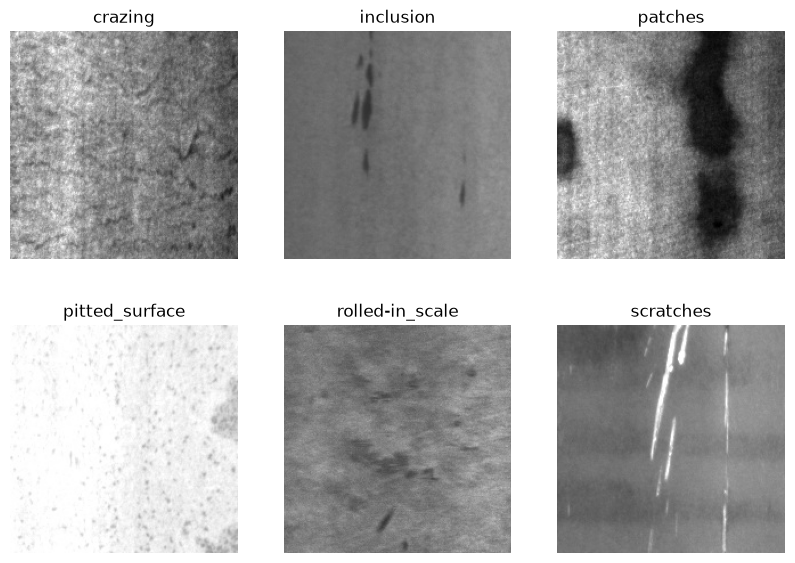

,index,brightness,contrast,sharpness
0,count,1439.000000,1439.000000,1439.000000
1,mean,0.503058,0.104993,0.011769
2,std,0.174861,0.060277,0.012631
3,min,0.136878,0.023419,0.000133
4,25%,0.364504,0.058531,0.001081
5,50%,0.492732,0.092551,0.006508
6,75%,0.612322,0.127410,0.021369
7,max,0.963323,0.288349,0.042525


In [5]:
def conditions(arrays):
    rows=[]
    for a in arrays:
        x=a.astype(np.float32)/255
        rows.append(dict(brightness=float(x.mean()),contrast=float(x.std()),sharpness=float(laplace(x,mode='reflect').var())))
    return pd.DataFrame(rows)
dev_conditions=conditions(images)
cutpoints={k:np.quantile(dev_conditions[k],[1/3,2/3]).tolist() for k in dev_conditions}
save_json('subgroup_cutpoints.json',cutpoints)
fig,axes=plt.subplots(2,3,figsize=(10,7))
for c,ax in enumerate(axes.flat):
    i=np.flatnonzero(y==c)[0]; ax.imshow(images[i],cmap='gray',vmin=0,vmax=255); ax.set_title(CLASSES[c]); ax.axis('off')
figure('development_examples')
table('development_condition_summary',dev_conditions.describe().reset_index())

## 6. HOG-SVM development

HOG encodes local gradient orientations using nine bins, 16 by 16 pixel cells and 2 by 2 cell blocks with L2-Hys normalisation [3]. Incomplete border cells are omitted. Descriptor computation is independent of labels and does not fit statistics. Standardisation and SVM fitting occur inside each training fold [4]. Store every candidate score, select by mean fold macro F1 and retain selected out-of-fold predictions for descriptive development comparison.

In [6]:
def features(arrays): return np.stack([hog(a.astype(np.float32)/255,**HOG) for a in arrays])
t=perf_counter(); X=features(images); hog_dev_seconds=perf_counter()-t
svm_rows=[]; candidate_oof={}
t_cv=perf_counter()
for cid,params in enumerate(CANDIDATES):
    pred=np.full(len(y),-1,dtype=int)
    for fold,(tr,va) in enumerate(folds):
        model=make_pipeline(StandardScaler(),SVC(**params))
        t=perf_counter(); model.fit(X[tr],y[tr]); fit_seconds=perf_counter()-t
        pred[va]=model.predict(X[va])
        svm_rows.append(dict(candidate=cid,fold=fold,**params,**metrics(y[va],pred[va]),fit_seconds=fit_seconds))
        save_json('progress.json',dict(stage='svm_cv',candidate=cid,fold=fold))
    candidate_oof[cid]=pred
    print('Completed SVM candidate',cid,params,flush=True)
svm_cv_seconds=perf_counter()-t_cv
svm_folds=pd.DataFrame(svm_rows)
svm_summary=svm_folds.groupby('candidate',as_index=False).agg(mean_f1=('f1_macro','mean'),sd_f1=('f1_macro','std'),fit_seconds=('fit_seconds','sum'))
best_id=int(svm_summary.sort_values(['mean_f1','candidate'],ascending=[False,True]).iloc[0].candidate)
best_params=CANDIDATES[best_id]
svm_oof=candidate_oof[best_id]
table('svm_candidate_folds',svm_folds)
table('svm_selection',svm_summary)
print('Selected SVM:',best_params,'HOG dimensions:',X.shape[1])

Completed SVM candidate 0 {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'}


Completed SVM candidate 1 {'kernel': 'linear', 'C': 1.0, 'gamma': 'scale'}


Completed SVM candidate 2 {'kernel': 'linear', 'C': 10.0, 'gamma': 'scale'}


Completed SVM candidate 3 {'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale'}


Completed SVM candidate 4 {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}


Completed SVM candidate 5 {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}


,candidate,fold,kernel,C,gamma,accuracy,precision_macro,recall_macro,f1_macro,fit_seconds
0,0,0,linear,0.1,scale,0.843750,0.841307,0.843750,0.840810,8.408685
1,0,1,linear,0.1,scale,0.819444,0.824166,0.819444,0.817495,8.279970
2,0,2,linear,0.1,scale,0.847222,0.846972,0.847222,0.846153,4.914660
3,0,3,linear,0.1,scale,0.829861,0.830064,0.829861,0.827595,1.765261
4,0,4,linear,0.1,scale,0.829268,0.841633,0.828531,0.827578,1.734906
5,1,0,linear,1.0,scale,0.843750,0.841307,0.843750,0.840810,2.177154
6,1,1,linear,1.0,scale,0.819444,0.824166,0.819444,0.817495,1.953506
7,1,2,linear,1.0,scale,0.847222,0.846972,0.847222,0.846153,1.658499
8,1,3,linear,1.0,scale,0.829861,0.830064,0.829861,0.827595,1.597409
9,1,4,linear,1.0,scale,0.829268,0.841633,0.828531,0.827578,1.649859


,candidate,mean_f1,sd_f1,fit_seconds
0,0,0.831926,0.011481,25.103482
1,1,0.831926,0.011481,9.036427
2,2,0.831926,0.011481,8.623221
3,3,0.709126,0.038219,35.278847
4,4,0.877231,0.011219,37.521219
5,5,0.887114,0.012463,54.307921


Selected SVM: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'} HOG dimensions: 4356


## 7. Compact CNN implementation and training procedure

Convert each greyscale image to one float channel at its native size. Estimate pixel mean and population standard deviation using only each fold's training images. Reuse those values for its validation images. The first convolution has stride two to bound CPU cost; subsequent pooling and global averaging reduce spatial detail. This architecture trades representational capacity and explanation resolution against compute. It is an independently trained custom model, with no transfer learning or augmentation.

The DataLoader uses a dedicated seeded generator and no workers. Deterministic CPU algorithms are requested, while cross-platform bitwise identity is not assumed. At each epoch, report both training and validation metrics in evaluation mode using the same weights; online optimisation loss is separate. Save every improving checkpoint and the full learning history. A patience stop describes this rule's local plateau, not global convergence.

In [7]:
class GreyDataset(Dataset):
    def __init__(self,arrays,labels,indices,mean,std):
        self.arrays,self.labels,self.indices=arrays,labels,np.asarray(indices)
        self.mean,self.std=float(mean),float(std)
    def __len__(self): return len(self.indices)
    def __getitem__(self,index):
        i=int(self.indices[index])
        x=torch.from_numpy(self.arrays[i]).unsqueeze(0).float()/255
        return (x-self.mean)/self.std,int(self.labels[i])
def loader(arrays,labels,indices,mean,std,shuffle=False,seed=SEED):
    return DataLoader(GreyDataset(arrays,labels,indices,mean,std),batch_size=CONFIG['batch_size'],shuffle=shuffle,num_workers=0,drop_last=False,generator=torch.Generator().manual_seed(seed))
def normalisation(indices):
    mean=float(images[indices].mean(dtype=np.float64)/255)
    std=float(images[indices].std(dtype=np.float64)/255)
    assert std>1e-8
    return mean,std
class CompactCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(1,8,3,stride=2,padding=1,bias=False); self.bn1=nn.BatchNorm2d(8)
        self.conv2=nn.Conv2d(8,16,3,padding=1,bias=False); self.bn2=nn.BatchNorm2d(16)
        self.conv3=nn.Conv2d(16,32,3,padding=1,bias=False); self.bn3=nn.BatchNorm2d(32)
        self.relu=nn.ReLU(inplace=False); self.pool=nn.MaxPool2d(2)
        self.average=nn.AdaptiveAvgPool2d((1,1)); self.dropout=nn.Dropout(CONFIG['dropout'])
        self.classifier=nn.Linear(32,6)
    def forward(self,x):
        x=self.pool(self.relu(self.bn1(self.conv1(x))))
        x=self.pool(self.relu(self.bn2(self.conv2(x))))
        x=self.pool(self.relu(self.bn3(self.conv3(x))))
        return self.classifier(self.dropout(self.average(x).flatten(1)))
def new_model(seed):
    seed_all(seed)
    return CompactCNN()
def train_epoch(model,batches,optimiser):
    model.train(); loss_sum=0.; n=0
    for xb,yb in batches:
        optimiser.zero_grad(set_to_none=True)
        loss=nn.functional.cross_entropy(model(xb),yb)
        loss.backward(); optimiser.step()
        loss_sum+=loss.item()*len(yb); n+=len(yb)
    return loss_sum/n
def evaluate(model,batches):
    model.eval(); predictions=[]; truths=[]; loss_sum=0.; n=0
    with torch.inference_mode():
        for xb,yb in batches:
            logits=model(xb)
            loss_sum+=nn.functional.cross_entropy(logits,yb,reduction='sum').item(); n+=len(yb)
            predictions.extend(logits.argmax(1).numpy().tolist()); truths.extend(yb.numpy().tolist())
    return np.asarray(predictions),loss_sum/n,metrics(truths,predictions)
fold_norms=[normalisation(tr) for tr,va in folds]
table('fold_normalisation',pd.DataFrame([dict(fold=f,mean=m,std=s,training_n=len(folds[f][0])) for f,(m,s) in enumerate(fold_norms)]))
def run_cnn_cv(cap):
    results=[]; histories=[]; oof=np.full(len(y),-1,int)
    for fold,(tr,va) in enumerate(folds):
        seed=SEED+fold; mean,std=fold_norms[fold]
        model=new_model(seed)
        train_batches=loader(images,y,tr,mean,std,True,seed)
        train_eval=loader(images,y,tr,mean,std)
        valid_batches=loader(images,y,va,mean,std)
        optimiser=torch.optim.AdamW(model.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
        best=-math.inf; best_epoch=0; stale=0; history=[]
        checkpoint=RUN/f'cnn_cap{cap}_fold{fold}.pt'
        start=perf_counter()
        for epoch in range(1,cap+1):
            t=perf_counter(); online_loss=train_epoch(model,train_batches,optimiser); fit_s=perf_counter()-t
            _,train_loss,train_m=evaluate(model,train_eval)
            vp,valid_loss,valid_m=evaluate(model,valid_batches)
            improved=valid_m['f1_macro']>best
            if improved:
                best=valid_m['f1_macro']; best_epoch=epoch; stale=0
                torch.save(model.state_dict(),checkpoint)
            else: stale+=1
            record=dict(cap=cap,fold=fold,epoch=epoch,online_loss=online_loss,train_loss=train_loss,validation_loss=valid_loss,train_f1=train_m['f1_macro'],validation_f1=valid_m['f1_macro'],patience_used=stale,fit_seconds=fit_s)
            history.append(record)
            pd.DataFrame(history).to_csv(RUN/f'history_cap{cap}_fold{fold}.csv',index=False)
            save_json('progress.json',dict(stage='cnn_cv',cap=cap,fold=fold,epoch=epoch))
            print(f'CNN cap {cap}, fold {fold+1}, epoch {epoch}: validation macro F1={valid_m["f1_macro"]:.4f}',flush=True)
            if stale>=CONFIG['patience']: break
        model.load_state_dict(torch.load(checkpoint,map_location='cpu',weights_only=True))
        vp,_,selected=evaluate(model,valid_batches); oof[va]=vp
        results.append(dict(cap=cap,fold=fold,best_epoch=best_epoch,epochs_run=epoch,stop_reason='patience' if stale>=CONFIG['patience'] else 'epoch_limit',wall_seconds=perf_counter()-start,**selected))
        histories.extend(history)
    assert np.all(oof>=0)
    return pd.DataFrame(results),pd.DataFrame(histories),oof
cnn25,hist25,oof25=run_cnn_cv(25)
table('cnn25_folds',cnn25)

,fold,mean,std,training_n
0,0,0.504116,0.211441,1151
1,1,0.502400,0.213103,1151
2,2,0.502099,0.211518,1151
3,3,0.505010,0.213203,1151
4,4,0.501666,0.213830,1152


CNN cap 25, fold 1, epoch 1: validation macro F1=0.3430


CNN cap 25, fold 1, epoch 2: validation macro F1=0.8051


CNN cap 25, fold 1, epoch 3: validation macro F1=0.8459


CNN cap 25, fold 1, epoch 4: validation macro F1=0.8788


...

CNN cap 25, fold 5, epoch 22: validation macro F1=0.8806


CNN cap 25, fold 5, epoch 23: validation macro F1=0.9478


CNN cap 25, fold 5, epoch 24: validation macro F1=0.9408


CNN cap 25, fold 5, epoch 25: validation macro F1=0.9444


,cap,fold,best_epoch,epochs_run,stop_reason,wall_seconds,accuracy,precision_macro,recall_macro,f1_macro
0,25,0,20,25,patience,119.458908,0.965278,0.965586,0.965278,0.965152
1,25,1,15,20,patience,145.009725,0.927083,0.935109,0.927083,0.927876
2,25,2,8,13,patience,86.233978,0.892361,0.899027,0.892361,0.893120
3,25,3,23,25,epoch_limit,166.383578,0.954861,0.956500,0.954861,0.954774
4,25,4,23,25,epoch_limit,164.971502,0.947735,0.950251,0.947917,0.947815


## 8. Controlled 25 versus 40 epoch-cap sensitivity

The extended run repeats the same initialisations, fold normalisation, data order, optimiser and stopping rule. Verify overlapping training trajectories before attributing any change to the cap. Report paired fold deltas, selected epochs, stopping reasons and elapsed time even when changes are unfavourable. The decision rule in Section 1 determines the final cap without test access. The median-epoch refit rule remains unchanged.

CNN cap 40, fold 1, epoch 1: validation macro F1=0.3430


CNN cap 40, fold 1, epoch 2: validation macro F1=0.8051


CNN cap 40, fold 1, epoch 3: validation macro F1=0.8459


CNN cap 40, fold 1, epoch 4: validation macro F1=0.8788


CNN cap 40, fold 1, epoch 5: validation macro F1=0.8835


...

CNN cap 40, fold 5, epoch 27: validation macro F1=0.9271


CNN cap 40, fold 5, epoch 28: validation macro F1=0.9249


,cap,fold,best_epoch,epochs_run,stop_reason,wall_seconds,accuracy,precision_macro,recall_macro,f1_macro
0,40,0,20,25,patience,166.472790,0.965278,0.965586,0.965278,0.965152
1,40,1,15,20,patience,141.872948,0.927083,0.935109,0.927083,0.927876
2,40,2,8,13,patience,94.103776,0.892361,0.899027,0.892361,0.893120
3,40,3,23,28,patience,184.433819,0.954861,0.956500,0.954861,0.954774
4,40,4,23,28,patience,191.362157,0.947735,0.950251,0.947917,0.947815


,cap_25,fold,best_epoch_25,epochs_run_25,stop_reason_25,wall_seconds_25,accuracy_25,precision_macro_25,recall_macro_25,f1_macro_25,cap_40,best_epoch_40,epochs_run_40,stop_reason_40,wall_seconds_40,accuracy_40,precision_macro_40,recall_macro_40,f1_macro_40,delta_f1
0,25,0,20,25,patience,119.458908,0.965278,0.965586,0.965278,0.965152,40,20,25,patience,166.472790,0.965278,0.965586,0.965278,0.965152,0.0
1,25,1,15,20,patience,145.009725,0.927083,0.935109,0.927083,0.927876,40,15,20,patience,141.872948,0.927083,0.935109,0.927083,0.927876,0.0
2,25,2,8,13,patience,86.233978,0.892361,0.899027,0.892361,0.893120,40,8,13,patience,94.103776,0.892361,0.899027,0.892361,0.893120,0.0
3,25,3,23,25,epoch_limit,166.383578,0.954861,0.956500,0.954861,0.954774,40,23,28,patience,184.433819,0.954861,0.956500,0.954861,0.954774,0.0
4,25,4,23,25,epoch_limit,164.971502,0.947735,0.950251,0.947917,0.947815,40,23,28,patience,191.362157,0.947735,0.950251,0.947917,0.947815,0.0


,chosen_cap,refit_epochs,decision,prefix_matches,prefix_max_errors,material_folds,natural_stops,mean_delta
0,25,20,retain 25: adequate under this bounded check,True,"{'online_loss': 0.0, 'train_loss': 0.0, 'valid...",0,5,0.0


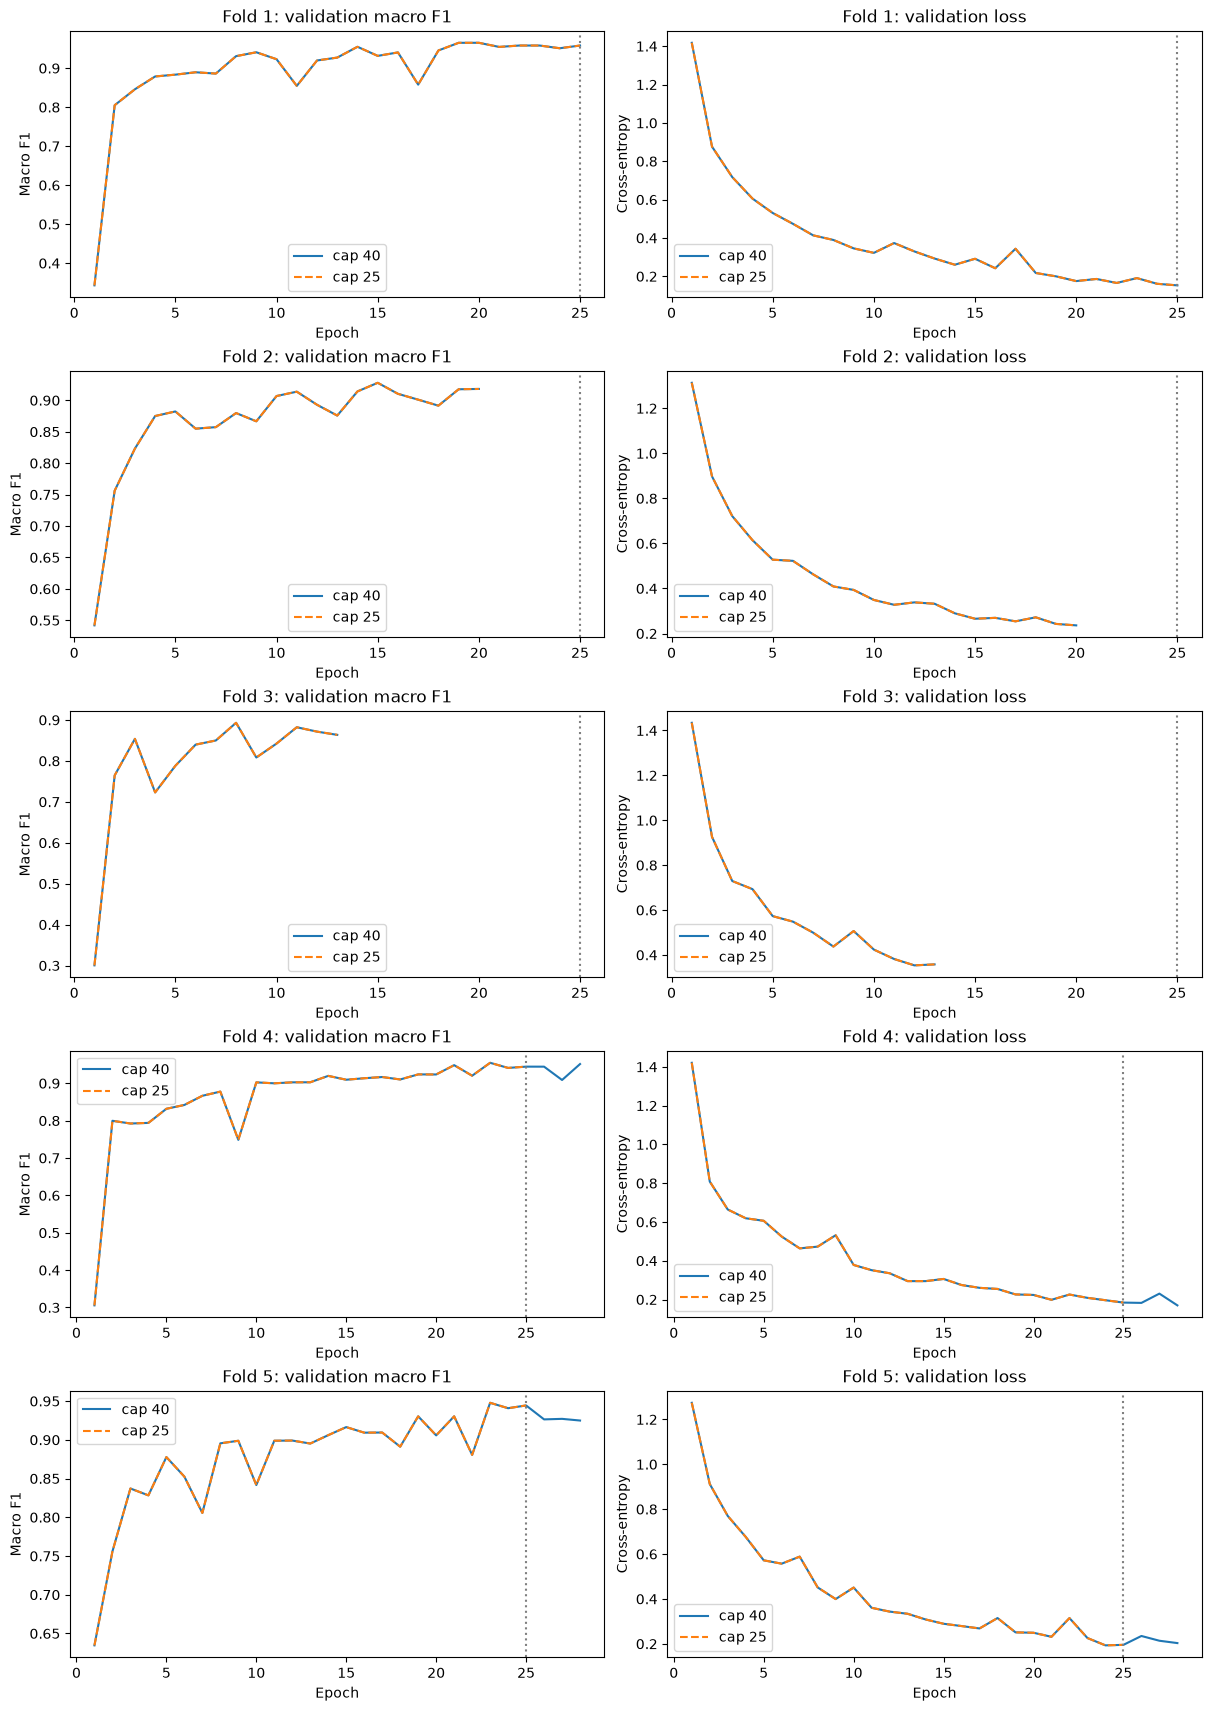

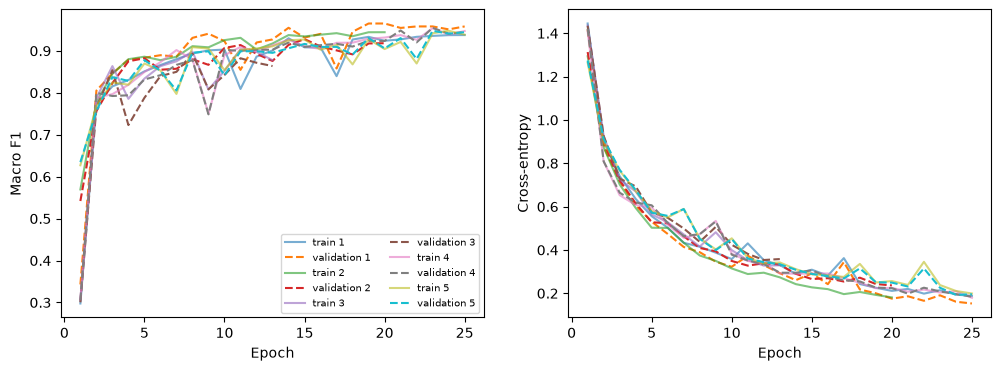

,model,metric,fold_mean,fold_sd,pooled_oof
0,HOG-SVM,accuracy,0.888804,0.012121,0.888812
1,HOG-SVM,precision_macro,0.891109,0.011046,0.890043
2,HOG-SVM,recall_macro,0.888697,0.012242,0.888732
3,HOG-SVM,f1_macro,0.887114,0.012463,0.887198
4,CNN,accuracy,0.937464,0.028826,0.937457
5,CNN,precision_macro,0.941295,0.026107,0.939719
6,CNN,recall_macro,0.937500,0.028842,0.937465
7,CNN,f1_macro,0.937747,0.028422,0.937723


In [8]:
cnn40,hist40,oof40=run_cnn_cv(40)
paired=cnn25.merge(cnn40,on='fold',suffixes=('_25','_40'),validate='one_to_one')
paired['delta_f1']=paired.f1_macro_40-paired.f1_macro_25
prefix=hist25.merge(hist40,on=['fold','epoch'],suffixes=('_25','_40'),validate='one_to_one')
trajectory=['online_loss','train_loss','validation_loss','train_f1','validation_f1','patience_used']
prefix_errors={k:float(np.max(np.abs(prefix[k+'_25']-prefix[k+'_40']))) for k in trajectory}
prefix_ok=len(prefix)==len(hist25) and max(prefix_errors.values())<=1e-10
material=(paired.delta_f1.ge(.005)&paired.stop_reason_25.eq('epoch_limit')&paired.best_epoch_40.gt(25))
natural=(cnn40.stop_reason.eq('patience')&cnn40.epochs_run.lt(40)).sum()
if prefix_ok and material.sum()>=2:
    chosen_cap=40; adequacy='adopt 40: material improvements in previously truncated folds'
elif prefix_ok and abs(paired.delta_f1.mean())<=.002 and not paired.delta_f1.ge(.005).any() and natural>=3:
    chosen_cap=25; adequacy='retain 25: adequate under this bounded check'
else:
    chosen_cap=25; adequacy='retain 25 provisionally: inconclusive adequacy'
selected_cnn=cnn25 if chosen_cap==25 else cnn40
cnn_oof=oof25 if chosen_cap==25 else oof40
refit_epochs=int(math.ceil(selected_cnn.best_epoch.median()))
decision=dict(chosen_cap=chosen_cap,refit_epochs=refit_epochs,decision=adequacy,prefix_matches=bool(prefix_ok),prefix_max_errors=prefix_errors,material_folds=int(material.sum()),natural_stops=int(natural),mean_delta=float(paired.delta_f1.mean()))
save_json('sensitivity_decision.json',decision)
table('cnn40_folds',cnn40)
table('epoch_cap_comparison',paired)
display(pd.DataFrame([decision]))
fig,axes=plt.subplots(5,2,figsize=(12,17),layout='constrained')
for fold in range(5):
    for data,style,label in [(hist40,'-','cap 40'),(hist25,'--','cap 25')]:
        h=data.loc[data.fold.eq(fold)]
        axes[fold,0].plot(h.epoch,h.validation_f1,style,label=label)
        axes[fold,1].plot(h.epoch,h.validation_loss,style,label=label)
    axes[fold,0].set(title=f'Fold {fold+1}: validation macro F1',xlabel='Epoch',ylabel='Macro F1')
    axes[fold,1].set(title=f'Fold {fold+1}: validation loss',xlabel='Epoch',ylabel='Cross-entropy')
    for ax in axes[fold]: ax.axvline(25,color='grey',linestyle=':'); ax.legend()
figure('epoch_cap_sensitivity')
fig,axes=plt.subplots(1,2,figsize=(12,4))
selected_history=hist25 if chosen_cap==25 else hist40
for fold in range(5):
    h=selected_history.loc[selected_history.fold.eq(fold)]
    axes[0].plot(h.epoch,h.train_f1,label=f'train {fold+1}',alpha=.6)
    axes[0].plot(h.epoch,h.validation_f1,'--',label=f'validation {fold+1}')
    axes[1].plot(h.epoch,h.train_loss,alpha=.6)
    axes[1].plot(h.epoch,h.validation_loss,'--')
axes[0].set(xlabel='Epoch',ylabel='Macro F1'); axes[0].legend(fontsize=7,ncol=2)
axes[1].set(xlabel='Epoch',ylabel='Cross-entropy')
figure('selected_cnn_learning_curves')
development_predictions=development[['path','class_name','fold']].copy()
development_predictions['svm_pred']=[CLASSES[i] for i in svm_oof]
development_predictions['cnn_pred']=[CLASSES[i] for i in cnn_oof]
development_predictions.to_csv(RUN/'development_oof_predictions.csv',index=False)
dev_summary=[]
for name,frame,pred in [('HOG-SVM',svm_folds.loc[svm_folds.candidate.eq(best_id)],svm_oof),('CNN',selected_cnn,cnn_oof)]:
    for key in metrics(y,pred):
        dev_summary.append(dict(model=name,metric=key,fold_mean=frame[key].mean(),fold_sd=frame[key].std(ddof=1),pooled_oof=metrics(y,pred)[key]))
table('development_comparison',pd.DataFrame(dev_summary))

## 9. Final refitting and specification freeze

Refit the selected SVM pipeline on all development descriptors. Train a fresh CNN on all development images for the predeclared derived epoch count, estimating its normalisation from development only. There is no final test-guided checkpoint selection. Save both models, verify serialisation using development examples, and hash the files. The freeze record binds model hashes, selection settings, split, folds, subgroup boundaries and perturbations before the test gate opens.

In [9]:
t=perf_counter(); final_svm=make_pipeline(StandardScaler(),SVC(**best_params)); final_svm.fit(X,y); svm_refit_seconds=perf_counter()-t
joblib.dump(dict(pipeline=final_svm,hog=HOG,classes=CLASSES),RUN/'final_svm.joblib')
assert np.array_equal(joblib.load(RUN/'final_svm.joblib')['pipeline'].predict(X[:32]),final_svm.predict(X[:32]))
final_mean,final_std=normalisation(np.arange(len(y)))
final_cnn=new_model(SEED+100)
final_batches=loader(images,y,np.arange(len(y)),final_mean,final_std,True,SEED+100)
optimiser=torch.optim.AdamW(final_cnn.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
refit_history=[]; t=perf_counter()
for epoch in range(1,refit_epochs+1):
    loss=train_epoch(final_cnn,final_batches,optimiser)
    refit_history.append(dict(epoch=epoch,online_train_loss=loss))
    print('Final CNN refit epoch',epoch,'of',refit_epochs,flush=True)
cnn_refit_seconds=perf_counter()-t
final_cnn.eval()
torch.save(dict(state_dict=final_cnn.state_dict(),mean=final_mean,std=final_std,classes=CLASSES,epochs=refit_epochs,cap=chosen_cap),RUN/'final_cnn.pt')
payload=torch.load(RUN/'final_cnn.pt',map_location='cpu',weights_only=True)
restored=CompactCNN(); restored.load_state_dict(payload['state_dict']); restored.eval()
probe=loader(images,y,np.arange(32),final_mean,final_std)
assert np.array_equal(evaluate(restored,probe)[0],evaluate(final_cnn,probe)[0])
table('cnn_final_training_history',pd.DataFrame(refit_history))
assert all(r['path'] in set(development.path) and r['stage']=='development' for r in raw_access)
assert sha(RUN/'protocol.json')==PROTOCOL_SHA
frozen=dict(time_utc=datetime.now(timezone.utc).isoformat(),svm=best_params,cnn=decision,cnn_mean=final_mean,cnn_std=final_std,svm_sha256=sha(RUN/'final_svm.joblib'),cnn_sha256=sha(RUN/'final_cnn.pt'),split_sha256=SPLIT_SHA,fold_sha256=FOLD_SHA,protocol_sha256=PROTOCOL_SHA,cutpoints=cutpoints,stress=STRESS,pre_freeze_test_reads=0)
save_json('freeze.json',frozen); FREEZE_SHA=sha(RUN/'freeze.json')
freeze_access_count=len(raw_access)
stage='frozen_evaluation'
print('Specifications frozen; test gate opened.',frozen['time_utc'])

Final CNN refit epoch 1 of 20


Final CNN refit epoch 2 of 20


Final CNN refit epoch 3 of 20


Final CNN refit epoch 4 of 20


Final CNN refit epoch 5 of 20


...

Final CNN refit epoch 18 of 20


Final CNN refit epoch 19 of 20


Final CNN refit epoch 20 of 20


,epoch,online_train_loss
0,1,1.356359
1,2,1.007624
2,3,0.801518
3,4,0.674886
4,5,0.592580
5,6,0.518070
6,7,0.454911
7,8,0.421852
8,9,0.398464
9,10,0.376093


Specifications frozen; test gate opened. 2026-09-27T20:18:00.300038+00:00


## 10. One primary locked-test evaluation

Load the reserved test images only after the freeze record exists. Both models predict the same ordered images. Cache clean predictions for all later clean diagnostics. Report the four required aggregate metrics, classwise precision/recall/F1/support and confusion matrices. Row-normalised confusion matrices show the distribution of predictions within each true class; counts expose sample size.

The partition is internal to this benchmark, with unknown acquisition-group independence. It cannot demonstrate transfer to other factories, cameras, steel grades or unrepresented defects. No model setting is changed in response to this section.

,model,n,accuracy,precision_macro,recall_macro,f1_macro
0,HOG-SVM,360,0.902778,0.905498,0.902778,0.902302
1,CNN,360,0.955556,0.961108,0.955556,0.955493


,class_or_average,precision,recall,f1-score,support
0,crazing,0.921875,0.983333,0.951613,60.0
1,inclusion,0.800000,0.933333,0.861538,60.0
2,patches,0.905660,0.800000,0.849558,60.0
3,pitted_surface,0.894737,0.850000,0.871795,60.0
4,rolled-in_scale,1.000000,1.000000,1.000000,60.0
5,scratches,0.910714,0.850000,0.879310,60.0
6,macro avg,0.905498,0.902778,0.902302,360.0
7,weighted avg,0.905498,0.902778,0.902302,360.0


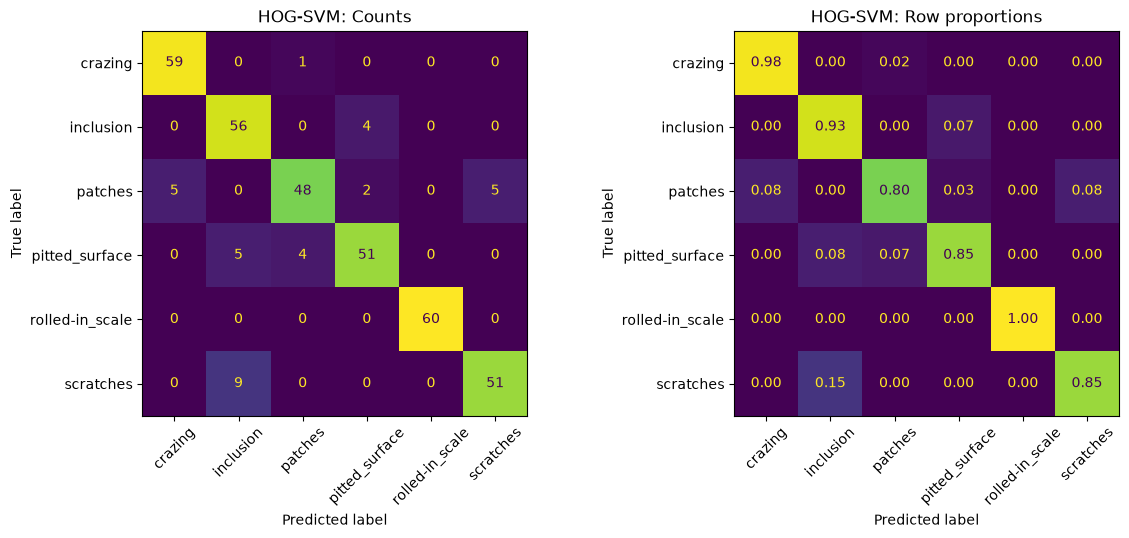

,class_or_average,precision,recall,f1-score,support
0,crazing,0.983051,0.966667,0.974790,60.0
1,inclusion,0.833333,1.000000,0.909091,60.0
2,patches,0.967213,0.983333,0.975207,60.0
3,pitted_surface,1.000000,0.816667,0.899083,60.0
4,rolled-in_scale,1.000000,1.000000,1.000000,60.0
5,scratches,0.983051,0.966667,0.974790,60.0
6,macro avg,0.961108,0.955556,0.955493,360.0
7,weighted avg,0.961108,0.955556,0.955493,360.0


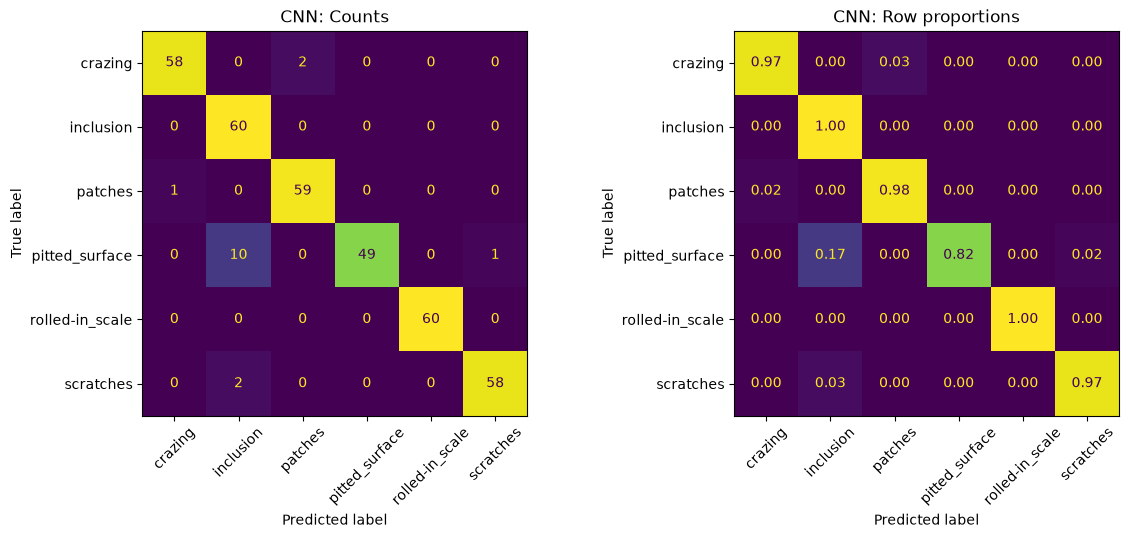

In [10]:
assert stage=='frozen_evaluation' and sha(RUN/'freeze.json')==FREEZE_SHA
t=perf_counter(); test_images=load_images(test_manifest); decode_test_seconds=perf_counter()-t
yt=np.array([CLASSES.index(c) for c in test_manifest.class_name],dtype=np.int64)
def cnn_predict(arrays):
    batches=loader(arrays,np.zeros(len(arrays),dtype=int),np.arange(len(arrays)),final_mean,final_std)
    final_cnn.eval(); predictions=[]
    with torch.inference_mode():
        for xb,_ in batches: predictions.extend(final_cnn(xb).argmax(1).numpy().tolist())
    return np.asarray(predictions,dtype=int)
test_features=features(test_images)
clean_predictions={'HOG-SVM':final_svm.predict(test_features),'CNN':cnn_predict(test_images)}
test_results=pd.DataFrame([dict(model=name,n=len(yt),**metrics(yt,pred)) for name,pred in clean_predictions.items()])
table('test_results',test_results)
prediction_table=test_manifest[['path','class_name']].copy()
for name,pred in clean_predictions.items(): prediction_table[name]=[CLASSES[i] for i in pred]
prediction_table.to_csv(RUN/'test_predictions.csv',index=False)
for name,pred in clean_predictions.items():
    report_dict=classification_report(yt,pred,labels=range(6),target_names=CLASSES,output_dict=True,zero_division=0)
    report=pd.DataFrame({k:v for k,v in report_dict.items() if isinstance(v,dict)}).T.reset_index(names='class_or_average')
    table(name+'_per_class',report)
    cm=confusion_matrix(yt,pred,labels=range(6))
    pd.DataFrame(cm,index=CLASSES,columns=CLASSES).to_csv(RUN/(name+'_confusion_counts.csv'))
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    for ax,normalise,title in [(axes[0],None,'Counts'),(axes[1],'true','Row proportions')]:
        ConfusionMatrixDisplay.from_predictions(yt,pred,labels=range(6),display_labels=CLASSES,normalize=normalise,ax=ax,xticks_rotation=45,colorbar=False,values_format='d' if normalise is None else '.2f')
        ax.set_title(name+': '+title)
    figure(name+'_confusion')

## 11. Disagreement and error diagnostics

Tabulate paired correctness and directed confusions, retaining paths for inspection. Display up to twelve errors or disagreements in deterministic path order; this avoids choosing especially persuasive illustrations. A shared error does not identify its cause, and an agreement is not independent corroboration. These diagnostics are descriptive and cannot justify retuning on the test partition.

,svm_correct,cnn_correct,disagree,size
0,False,False,False,5
1,False,False,True,1
2,False,True,True,29
3,True,False,True,10
4,True,True,False,315


,model,true_class,predicted_class,count
10,CNN,pitted_surface,inclusion,10
7,HOG-SVM,scratches,inclusion,9
2,HOG-SVM,patches,crazing,5
4,HOG-SVM,patches,scratches,5
5,HOG-SVM,pitted_surface,inclusion,5
1,HOG-SVM,inclusion,pitted_surface,4
6,HOG-SVM,pitted_surface,patches,4
8,CNN,crazing,patches,2
12,CNN,scratches,inclusion,2
3,HOG-SVM,patches,pitted_surface,2


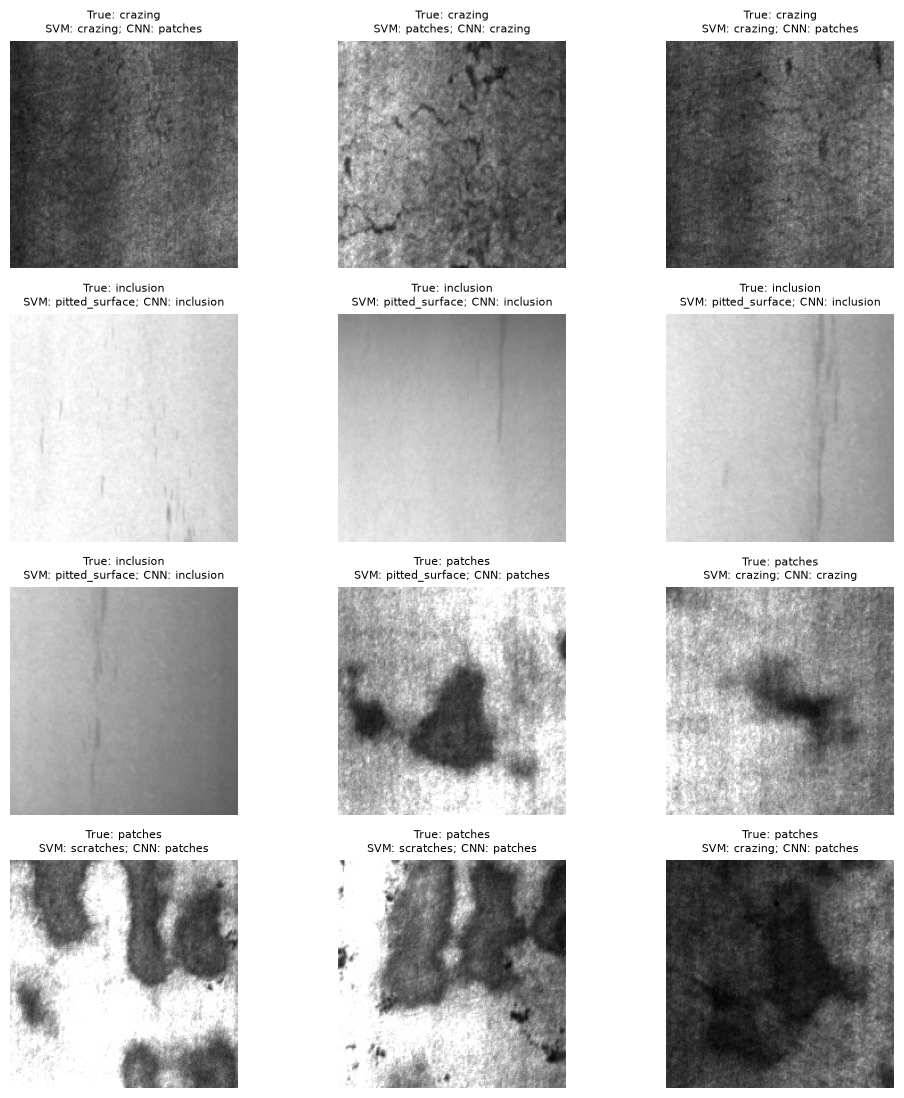

In [11]:
sp,cp=clean_predictions['HOG-SVM'],clean_predictions['CNN']
errors=prediction_table.copy()
errors['svm_correct']=sp==yt; errors['cnn_correct']=cp==yt; errors['disagree']=sp!=cp
table('paired_correctness',errors.groupby(['svm_correct','cnn_correct','disagree'],as_index=False).size())
errors.to_csv(RUN/'error_registry.csv',index=False)
directed=[]
for name,pred in clean_predictions.items():
    for truth in range(6):
        for guess in range(6):
            n=int(((yt==truth)&(pred==guess)).sum())
            if truth!=guess and n: directed.append(dict(model=name,true_class=CLASSES[truth],predicted_class=CLASSES[guess],count=n))
table('directed_errors',pd.DataFrame(directed,columns=['model','true_class','predicted_class','count']).sort_values(['count','model'],ascending=[False,True]))
chosen=np.flatnonzero((sp!=yt)|(cp!=yt)|(sp!=cp))[:12]
if len(chosen):
    fig,axes=plt.subplots(math.ceil(len(chosen)/3),3,figsize=(12,3.4*math.ceil(len(chosen)/3)),squeeze=False)
    for ax in axes.flat: ax.axis('off')
    for ax,i in zip(axes.flat,chosen):
        ax.imshow(test_images[i],cmap='gray',vmin=0,vmax=255)
        ax.set_title(f'True: {CLASSES[yt[i]]}\nSVM: {CLASSES[sp[i]]}; CNN: {CLASSES[cp[i]]}',fontsize=8)
    figure('error_examples')
else: print('No errors or disagreements for this run.')

## 12. CNN Grad-CAM and HOG representation

Use Captum LayerGradCam on the final convolutional layer, with the predicted class as target and ReLU applied to the attribution [5,6]. Upsample the coarse map for display and normalise each map independently; colour intensity is therefore not comparable across images. Select the first test example of each true class, then up to three errors in path order. Record target, true label and map range, including constant maps.

Grad-CAM describes local sensitivity in this model, not a causal explanation or validated defect boundary. Pooling limits resolution. No localisation ground truth or explanation faithfulness experiment is used here. HOG visualisation shows an input representation, **not SVM attribution**, and must not be read as a class-specific explanation.

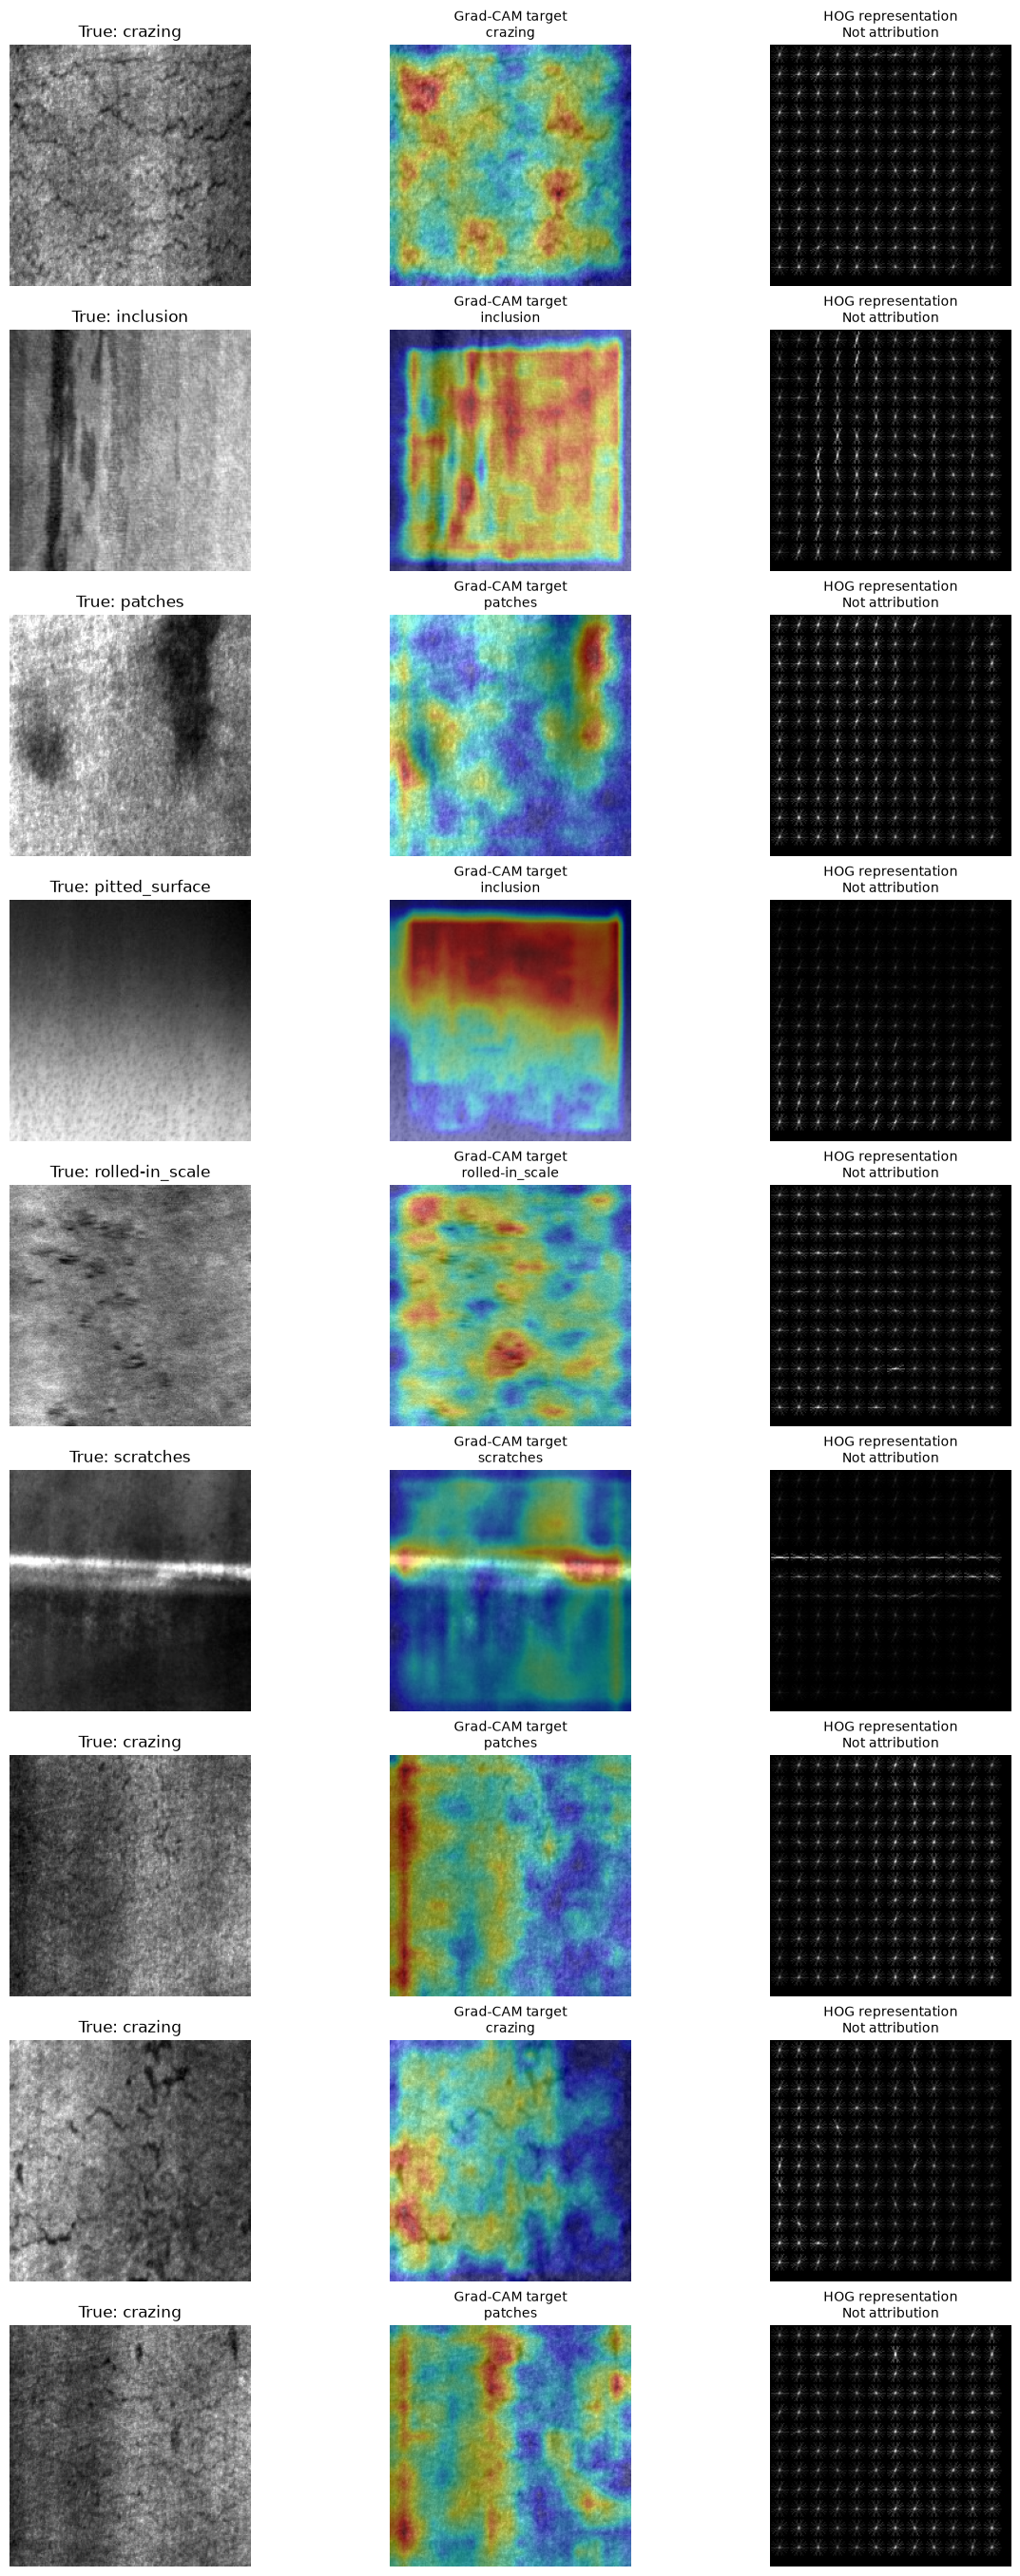

,path,true_class,target_class,cam_min,cam_max,constant_map
0,data/NEU-CLS/train/train/images/crazing_100.jpg,crazing,crazing,0.001049,0.016687,False
1,data/NEU-CLS/train/train/images/inclusion_102.jpg,inclusion,inclusion,0.000000,0.003646,False
2,data/NEU-CLS/train/train/images/patches_10.jpg,patches,patches,0.004107,0.025106,False
3,data/NEU-CLS/train/train/images/pitted_surface...,pitted_surface,inclusion,0.000000,0.004988,False
4,data/NEU-CLS/train/train/images/rolled-in_scal...,rolled-in_scale,rolled-in_scale,0.000000,0.011820,False
5,data/NEU-CLS/train/train/images/scratches_101.jpg,scratches,scratches,0.002796,0.014720,False
6,data/NEU-CLS/train/train/images/crazing_19.jpg,crazing,patches,0.004890,0.018390,False
7,data/NEU-CLS/train/train/images/crazing_294.jpg,crazing,crazing,0.000000,0.016139,False
8,data/NEU-CLS/train/train/images/crazing_77.jpg,crazing,patches,0.004920,0.018457,False


In [2]:
xai_indices=list(dict.fromkeys([int(np.flatnonzero(yt==c)[0]) for c in range(6)]+chosen[:3].tolist()))
cam=LayerGradCam(final_cnn,final_cnn.conv3)
xai_records=[]
fig,axes=plt.subplots(len(xai_indices),3,figsize=(12,3*len(xai_indices)),layout='constrained')
for row,i in enumerate(xai_indices):
    a=test_images[i]
    tensor=((torch.from_numpy(a).float()[None,None]/255-final_mean)/final_std).requires_grad_(True)
    attribution=cam.attribute(tensor,target=int(cp[i]),relu_attributions=True)
    assert torch.isfinite(attribution).all()
    heat=LayerAttribution.interpolate(attribution,(200,200),interpolate_mode='bilinear').detach().numpy()[0,0]
    lo,hi=float(heat.min()),float(heat.max()); scaled=(heat-lo)/(hi-lo) if hi>lo else np.zeros_like(heat)
    _,representation=hog(a.astype(np.float32)/255,visualize=True,**HOG)
    axes[row,0].imshow(a,cmap='gray'); axes[row,0].set_title('True: '+CLASSES[yt[i]])
    axes[row,1].imshow(a,cmap='gray'); axes[row,1].imshow(scaled,cmap='jet',alpha=.45,vmin=0,vmax=1)
    axes[row,1].set_title('Grad-CAM target'+chr(10)+CLASSES[cp[i]],fontsize=10)
    axes[row,2].imshow(representation,cmap='gray'); axes[row,2].set_title('HOG representation'+chr(10)+'Not attribution',fontsize=10)
    for ax in axes[row]: ax.axis('off')
    xai_records.append(dict(path=test_manifest.path.iloc[i],true_class=CLASSES[yt[i]],target_class=CLASSES[cp[i]],cam_min=lo,cam_max=hi,constant_map=hi==lo))
figure('explanations')
table('gradcam_registry',pd.DataFrame(xai_records))

## 13. Objective image-condition subgroups

Apply development-derived tertile boundaries without recomputing them on test images. Report subgroup size, all six class counts and the required metrics. Macro metrics always use the six-class label vocabulary, setting undefined values to zero; small or absent class supports limit comparisons. Brightness, contrast and sharpness groups overlap across diagnostic dimensions. Differences are associations and may reflect class composition, not independent effects of image quality.

In [13]:
test_conditions=conditions(test_images)
subgroups=[]; subgroup_composition=[]
for condition,cuts in cutpoints.items():
    bins=np.searchsorted(np.asarray(cuts),test_conditions[condition],side='left')
    for b,label in enumerate(['low','middle','high']):
        idx=np.flatnonzero(bins==b)
        counts=np.bincount(yt[idx],minlength=6)
        subgroup_composition.append(dict(condition=condition,group=label,n=len(idx),**dict(zip(CLASSES,counts))))
        for name,pred in clean_predictions.items():
            values=metrics(yt[idx],pred[idx]) if len(idx) else {k:np.nan for k in metrics(yt,pred)}
            subgroups.append(dict(condition=condition,group=label,model=name,n=len(idx),**values))
table('subgroup_composition',pd.DataFrame(subgroup_composition))
table('subgroup_metrics',pd.DataFrame(subgroups))

,condition,group,n,crazing,inclusion,patches,pitted_surface,rolled-in_scale,scratches
0,brightness,low,121,10,33,14,11,14,39
1,brightness,middle,118,25,17,11,9,39,17
2,brightness,high,121,25,10,35,40,7,4
3,contrast,low,120,0,51,0,11,36,22
4,contrast,middle,120,29,7,4,29,24,27
5,contrast,high,120,31,2,56,20,0,11
6,sharpness,low,121,0,60,0,20,0,41
7,sharpness,middle,118,0,0,11,40,48,19
8,sharpness,high,121,60,0,49,0,12,0


,condition,group,model,n,accuracy,precision_macro,recall_macro,f1_macro
0,brightness,low,HOG-SVM,121,0.917355,0.930235,0.898490,0.904302
1,brightness,low,CNN,121,0.958678,0.965278,0.932090,0.944293
2,brightness,middle,HOG-SVM,118,0.932203,0.934704,0.901929,0.910126
3,brightness,middle,CNN,118,0.940678,0.951389,0.879085,0.883161
4,brightness,high,HOG-SVM,121,0.859504,0.819181,0.836310,0.811915
5,brightness,high,CNN,121,0.966942,0.932479,0.982738,0.954153
6,contrast,low,HOG-SVM,120,0.933333,0.633658,0.602793,0.614296
7,contrast,low,CNN,120,0.966667,0.649832,0.613636,0.628013
8,contrast,middle,HOG-SVM,120,0.908333,0.833889,0.899380,0.853224
9,contrast,middle,CNN,120,0.933333,0.867521,0.953597,0.891846


## 14. Controlled mild robustness stress tests

Apply the frozen Gaussian blur, brightness factors, mean-centred contrast reduction and Gaussian noise independently to clean test images [7]. Use the same transformed arrays for both models, fixed noise seed, clipping to [0,1] and uint8 rounding. Report accuracy and macro F1 alongside changes from each model's cached clean score. There is no severity search or retraining.

These are synthetic stress tests, **not proof of real factory distribution-shift performance**. Perturbations are assumed to preserve defect labels at these mild severities, an assumption that needs domain validation. Real shifts can alter material, acquisition, prevalence and labels in ways these operators cannot represent [8].

,condition,model,n,accuracy,f1_macro,delta_accuracy,delta_f1
0,clean,HOG-SVM,360,0.902778,0.902302,0.000000,0.000000
1,clean,CNN,360,0.955556,0.955493,0.000000,0.000000
2,blur,HOG-SVM,360,0.772222,0.765914,-0.130556,-0.136389
3,blur,CNN,360,0.608333,0.554670,-0.347222,-0.400823
4,brightness_low,HOG-SVM,360,0.905556,0.905119,0.002778,0.002817
5,brightness_low,CNN,360,0.936111,0.936887,-0.019444,-0.018606
6,brightness_high,HOG-SVM,360,0.847222,0.847232,-0.055556,-0.055070
7,brightness_high,CNN,360,0.941667,0.940553,-0.013889,-0.014940
8,contrast,HOG-SVM,360,0.905556,0.904840,0.002778,0.002537
9,contrast,CNN,360,0.938889,0.939504,-0.016667,-0.015990


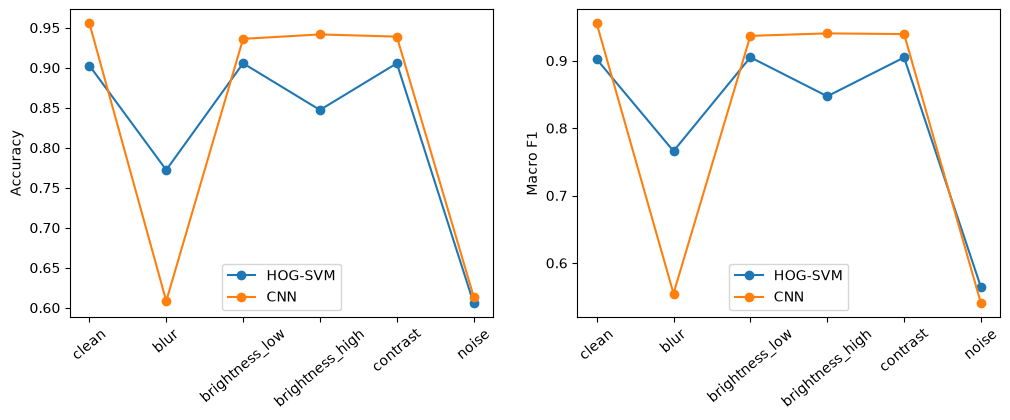

In [14]:
def perturb(arrays,name):
    x=arrays.astype(np.float32)/255
    if name=='blur': x=gaussian_filter(x,sigma=(0,STRESS['blur_sigma'],STRESS['blur_sigma']),mode='reflect')
    elif name=='brightness_low': x=x*STRESS['brightness_factors'][0]
    elif name=='brightness_high': x=x*STRESS['brightness_factors'][1]
    elif name=='contrast':
        mean=x.mean(axis=(1,2),keepdims=True); x=mean+STRESS['contrast_factor']*(x-mean)
    elif name=='noise': x=x+np.random.default_rng(STRESS['seed']).normal(0,STRESS['noise_sd'],x.shape)
    else: raise ValueError(name)
    return np.round(np.clip(x,0,1)*255).astype(np.uint8)
robust=[]
for name,pred in clean_predictions.items():
    m=metrics(yt,pred); robust.append(dict(condition='clean',model=name,n=len(yt),accuracy=m['accuracy'],f1_macro=m['f1_macro'],delta_accuracy=0.,delta_f1=0.))
for condition in ['blur','brightness_low','brightness_high','contrast','noise']:
    changed=perturb(test_images,condition)
    predictions={'HOG-SVM':final_svm.predict(features(changed)),'CNN':cnn_predict(changed)}
    for name,pred in predictions.items():
        m=metrics(yt,pred); clean=metrics(yt,clean_predictions[name])
        robust.append(dict(condition=condition,model=name,n=len(yt),accuracy=m['accuracy'],f1_macro=m['f1_macro'],delta_accuracy=m['accuracy']-clean['accuracy'],delta_f1=m['f1_macro']-clean['f1_macro']))
    pd.DataFrame({'path':test_manifest.path,**predictions}).to_csv(RUN/f'predictions_{condition}.csv',index=False)
robustness=pd.DataFrame(robust)
table('robustness',robustness)
fig,axes=plt.subplots(1,2,figsize=(12,4))
for name in clean_predictions:
    r=robustness.loc[robustness.model.eq(name)]
    axes[0].plot(r.condition,r.accuracy,'o-',label=name); axes[1].plot(r.condition,r.f1_macro,'o-',label=name)
for ax,label in zip(axes,['Accuracy','Macro F1']): ax.set_ylabel(label); ax.tick_params(axis='x',rotation=40); ax.legend()
figure('robustness_comparison')

## 15. Same-machine efficiency measurements

Report development feature extraction, candidate-search/CV time and final refit time separately. CNN CV timing includes epoch diagnostics and checkpointing, so it is not equivalent to pure optimisation time. Record parameter count, HOG dimension and serialised model file sizes.

For inference, use a fixed subset of development images, warm up each route three times, then take thirty timed single-image measurements. Report median and 95th percentile latency for decoding, preprocessing, classifier-only work and the combined route from file opening to prediction. OS file caching is warm. Measure batch throughput separately over the same development subset; do not infer it from single-image latency. CPU threads are recorded, and results depend on hardware, load and batching. Timing calls do not generate additional primary test scores. SVM inference includes scaling in its classifier pipeline; HOG extraction is a separate preprocessing cost.

In [15]:
def decode_one(path):
    with Image.open(path) as im: return np.array(im.convert('L'),dtype=np.uint8)
def normalise_one(a): return (torch.from_numpy(a).float()[None,None]/255-final_mean)/final_std
@torch.inference_mode()
def forward_one(x): return final_cnn(x).argmax(1)
sample_paths=[ROOT/p for p in development.path.iloc[:30]]
sample_arrays=images[:30]
def measure(fn):
    for i in range(3): fn(i)
    times=[]
    for i in range(30):
        t=perf_counter(); fn(i); times.append((perf_counter()-t)*1000)
    return dict(median_ms=float(np.median(times)),p95_ms=float(np.quantile(times,.95)),repeats=len(times))
routes={
    'shared_decode':lambda i:decode_one(sample_paths[i%30]),
    'svm_hog_preprocessing':lambda i:features(sample_arrays[i%30:i%30+1]),
    'svm_classifier_with_scaling':lambda i:final_svm.predict(X[i%30:i%30+1]),
    'svm_file_to_prediction':lambda i:final_svm.predict(features(decode_one(sample_paths[i%30])[None])),
    'cnn_normalisation':lambda i:normalise_one(sample_arrays[i%30]),
    'cnn_forward':lambda i:forward_one(normalised_samples[i%30]),
    'cnn_file_to_prediction':lambda i:forward_one(normalise_one(decode_one(sample_paths[i%30])))
}
normalised_samples=[normalise_one(a) for a in sample_arrays]
latency=pd.DataFrame([dict(route=name,**measure(fn)) for name,fn in routes.items()])
table('latency',latency)
throughput=[]
for name,fn in [('HOG-SVM',lambda a:final_svm.predict(features(a))),('CNN',cnn_predict)]:
    batch=images[:128]; fn(batch); durations=[]
    for _ in range(5):
        t=perf_counter(); fn(batch); durations.append(perf_counter()-t)
    throughput.append(dict(model=name,n=len(batch),batch_route='cached uint8 arrays through preprocessing and prediction',median_seconds=float(np.median(durations)),images_per_second=len(batch)/float(np.median(durations))))
table('throughput',pd.DataFrame(throughput))
efficiency=pd.DataFrame([
    dict(model='HOG-SVM',development_preprocessing_seconds=hog_dev_seconds,selection_seconds=svm_cv_seconds,refit_seconds=svm_refit_seconds,file_bytes=(RUN/'final_svm.joblib').stat().st_size,trainable_parameters=np.nan,hog_dimensions=X.shape[1]),
    dict(model='CNN',development_preprocessing_seconds=np.nan,selection_seconds=cnn25.wall_seconds.sum()+cnn40.wall_seconds.sum(),refit_seconds=cnn_refit_seconds,file_bytes=(RUN/'final_cnn.pt').stat().st_size,trainable_parameters=sum(p.numel() for p in final_cnn.parameters() if p.requires_grad),hog_dimensions=np.nan)
])
table('efficiency',efficiency)
save_json('timing_scope.json',dict(shared_development_decode_and_integrity_seconds=decode_dev_seconds,test_decode_and_integrity_seconds=decode_test_seconds,cnn25_wall_seconds=float(cnn25.wall_seconds.sum()),cnn40_wall_seconds=float(cnn40.wall_seconds.sum()),cnn_optimisation_seconds=float(hist25.fit_seconds.sum()+hist40.fit_seconds.sum()),cnn_preprocessing='normalisation occurs in loaders and is included in training/diagnostic timings; single-image cost separately measured'))

,route,median_ms,p95_ms,repeats
0,shared_decode,2.85205,5.685880,30
1,svm_hog_preprocessing,10.85950,13.731775,30
2,svm_classifier_with_scaling,11.66815,13.171680,30
3,svm_file_to_prediction,29.44940,35.591340,30
4,cnn_normalisation,0.32325,0.571725,30
5,cnn_forward,4.44560,5.664670,30
6,cnn_file_to_prediction,7.09575,8.840090,30


,model,n,batch_route,median_seconds,images_per_second
0,HOG-SVM,128,cached uint8 arrays through preprocessing and ...,2.969484,43.105134
1,CNN,128,cached uint8 arrays through preprocessing and ...,0.213181,600.429307


,model,development_preprocessing_seconds,selection_seconds,refit_seconds,file_bytes,trainable_parameters,hog_dimensions
0,HOG-SVM,27.25847,224.835336,15.386096,43632616,NaN,4356.0
1,CNN,NaN,1460.303181,107.802319,31963,6142.0,NaN


## 16. Ethics, limitations and deployment context

**Decision context.** A potential use is assisting a trained inspector in categorising already identified defect crops. Misclassification may misdirect remediation, while an automated acceptance decision could release unsafe material. This benchmark supplies no normal material, defect severity, downstream cost or acceptable-risk threshold. Consequently, neither a high aggregate metric nor a compelling heatmap justifies autonomous acceptance or rejection of steel.

**Evidence boundaries.** Image-level splitting cannot establish coil-, production-line- or factory-level independence without acquisition identifiers. Exact duplicate exclusion leaves near-duplicate risk. A small curated benchmark, one split and one initialisation per fold do not characterise deployment uncertainty. CV selection, epoch selection and the cap check share development evidence. Test subgroups can be small and class-confounded. Earlier familiarity with the benchmark limits claims of novelty and prospective blindness. Independent temporal and factory validation is needed before operational claims [2,8,9].

**Human oversight and accountability.** Retain qualified inspection, define escalation and abstention policies, document decision ownership and give operators a route to contest errors. Validate calibration and rejection thresholds on separate operational validation data before relying on confidence. Monitor class-specific failures and material/camera changes. Collect representative normal surfaces and out-of-scope defects, agree cost-sensitive acceptance criteria with process engineers and assess harmful false accepts separately from unnecessary rejects. Heatmaps cannot replace those controls.

**Data and reproducibility.** Attribute the dataset researchers and Figshare distributor, respect the stated distribution licence, record transformations and retain immutable raw inputs. Production images may expose proprietary processes or employee information even if this benchmark does not: minimise collection, control access and agree retention. Preserve versioned models, preprocessing and audit trails, define rollback and review responsibilities, and assess drift with labelled follow-up samples. Do not repurpose image-condition subgroup results as demographic fairness evidence.

**Resource use.** Bounded CPU training and explicit cost measurements make the computational budget visible, but latency is not energy use or a production service-level guarantee. Deployment assessment requires the actual acquisition pipeline, hardware, batch sizes, workload, maintenance and human review costs. No deployment approval is inferred from this notebook.

## 17. Completion and reproducibility checks

Verify the frozen specification and model files have not changed, all shared folds completed, test ordering is identical, values are finite and pre-freeze raw opens were development-only. Save the access record, checks and a machine-readable result summary in the fresh run directory. Inline outputs remain part of the submitted notebook; external run artefacts are useful for auditing but are not prerequisites for rerunning it.

To reproduce, use a fresh kernel and execute the entire notebook in order. Each full execution creates a new run directory. Do not select whichever repeated run happens to score best. If the raw audit fails, investigate the source discrepancy rather than changing acceptance checks to obtain a preferred result.

In [16]:
checks={
    'raw_count_and_unique_count':len(manifest)==1800 and int(manifest.included.sum())==1799,
    'split_sizes':len(development)==1439 and len(test_manifest)==360,
    'content_disjoint':not bool(set(development.pixel_sha256)&set(test_manifest.pixel_sha256)),
    'five_shared_folds':len(folds)==5 and bool(np.all(coverage==1)),
    'all_svm_candidates_complete':len(svm_folds)==30,
    'both_cnn_caps_complete':len(cnn25)==5 and len(cnn40)==5,
    'pre_freeze_development_only':all(r['path'] in set(development.path) and r['stage']=='development' for r in raw_access[:freeze_access_count]),
    'deliberate_test_request_denied':len(denied)==1,
    'same_test_order':all(len(p)==len(yt) for p in clean_predictions.values()),
    'test_predictions_finite':all(np.isfinite(p).all() for p in clean_predictions.values()),
    'metrics_finite':bool(np.isfinite(test_results.select_dtypes('number')).all().all()),
    'models_unchanged':sha(RUN/'final_svm.joblib')==frozen['svm_sha256'] and sha(RUN/'final_cnn.pt')==frozen['cnn_sha256'],
    'freeze_unchanged':sha(RUN/'freeze.json')==FREEZE_SHA,
    'protocol_unchanged':sha(RUN/'protocol.json')==PROTOCOL_SHA,
    'split_and_folds_unchanged':sha(RUN/'manifest.csv')==SPLIT_SHA and sha(RUN/'shared_folds.csv')==FOLD_SHA,
}
assert all(checks.values()), checks
table('acceptance_checks',pd.DataFrame(checks.items(),columns=['check','passed']))
pd.DataFrame(raw_access).to_csv(RUN/'raw_access_log.csv',index=False)
pd.DataFrame(denied).to_csv(RUN/'denied_access_log.csv',index=False)
save_json('result.json',dict(status='PASS',run=str(RUN),test_results=test_results.to_dict('records'),sensitivity=decision,checks=checks,pre_freeze_test_reads=0,scope='integrity audit before split; development-only access until freeze; primary clean predictions cached for diagnostics'))
save_json('status.json',dict(status='PASS',completed_utc=datetime.now(timezone.utc).isoformat()))
print('Completed fresh experiment:',RUN)
display(test_results)

,check,passed
0,raw_count_and_unique_count,True
1,split_sizes,True
2,content_disjoint,True
3,five_shared_folds,True
4,all_svm_candidates_complete,True
5,both_cnn_caps_complete,True
6,pre_freeze_development_only,True
7,deliberate_test_request_denied,True
8,same_test_order,True
9,test_predictions_finite,True


Completed fresh experiment: C:\Scripts\industrial-defect-intelligence\outputs\fresh_20260927T194627_610401Z


,model,n,accuracy,precision_macro,recall_macro,f1_macro
0,HOG-SVM,360,0.902778,0.905498,0.902778,0.902302
1,CNN,360,0.955556,0.961108,0.955556,0.955493


## References

1. Cao, W. (2025). *NEU-CLS*, version 1. Figshare. [Dataset DOI](https://doi.org/10.6084/m9.figshare.28903550.v1). [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). This is the distribution used here, not a claim that its packaging is identical to a separately hosted original archive.
2. Song, K. and Yan, Y. (2013). A noise robust method based on completed local binary patterns for hot-rolled steel strip surface defects. *Applied Surface Science*, 285, 858-864. [Original NEU database description and citation](https://faculty.neu.edu.cn/songkc/en/zdylm/263265/list/).
3. Dalal, N. and Triggs, B. (2005). Histograms of oriented gradients for human detection. *IEEE Computer Society Conference on Computer Vision and Pattern Recognition*, 1, 886-893. [Author-hosted paper](https://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf). The descriptor is adapted here to steel textures, not used as a pretrained detector.
4. Cortes, C. and Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20, 273-297. [DOI](https://doi.org/10.1007/BF00994018).
5. Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D. and Batra, D. (2017). Grad-CAM: Visual explanations from deep networks via gradient-based localization. *IEEE International Conference on Computer Vision*. [Paper and version history](https://arxiv.org/abs/1610.02391).
6. Captum. *Layer GradCAM API documentation*. [Official documentation](https://captum.ai/api/layer.html#layer-gradcam). The installed implementation version is recorded in the environment table.
7. Hendrycks, D. and Dietterich, T. (2019). Benchmarking neural network robustness to common corruptions and perturbations. *International Conference on Learning Representations*. [Paper](https://arxiv.org/abs/1903.12261). The mild operators here are a project-specific stress protocol, not an ImageNet-C benchmark score.
8. Koh, P. W. et al. (2021). WILDS: A benchmark of in-the-wild distribution shifts. *International Conference on Machine Learning*. [Paper](https://arxiv.org/abs/2012.07421).
9. He, Y., Song, K., Meng, Q. and Yan, Y. (2020). An end-to-end steel surface defect detection approach via fusing multiple hierarchical features. *IEEE Transactions on Instrumentation and Measurement*, 69(4), 1493-1504. [Original NEU research and citation listing](https://faculty.neu.edu.cn/songkc/en/zdylm/263265/list/). Its detection task differs from the crop-level classification studied here.